<a href="https://colab.research.google.com/github/zehra-aksoy/Veri-Bilimi-Proje/blob/main/Istanbul_Trafik_Analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Colab'e yüklediğin Kaggle dosyasının yolu
dosya_yolu = '/content/traffic_index.csv'

# Veriyi okuyoruz
df = pd.read_csv(dosya_yolu)

# 1. Verinin boyutunu (satır, sütun) kontrol edelim
print("Veri Setinin Boyutu (Satır, Sütun):", df.shape)

# 2. İlk 5 satıra bakarak veriyi görelim
print("\n--- Veri Setinin İlk 5 Satırı ---")
print(df.head())

# 3. Sütunların veri tiplerini ve eksik değer durumunu inceleyelim
print("\n--- Veri Tipleri ve Yapı Bilgisi ---")
print(df.info())

Veri Setinin Boyutu (Satır, Sütun): (3288, 4)

--- Veri Setinin İlk 5 Satırı ---
                  trafficindexdate  minimum_traffic_index  \
0  2022-08-14 00:00:00 +0000 +0000                      1   
1  2016-09-23 00:00:00 +0000 +0000                      2   
2  2019-03-31 00:00:00 +0000 +0000                      1   
3  2024-06-13 00:00:00 +0000 +0000                      1   
4  2019-01-12 00:00:00 +0000 +0000                      6   

   maximum_traffic_index  average_traffic_index  
0                     38              17.551854  
1                     76              36.892361  
2                     18               4.699301  
3                     81              43.719801  
4                     54              28.329825  

--- Veri Tipleri ve Yapı Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0  

In [ ]:
import pandas as pd

# 1. Tarih sütununu gerçek tarih formatına dönüştürüyoruz (ilk 10 karakteri alarak temizliyoruz)
df['trafficindexdate'] = pd.to_datetime(df['trafficindexdate'].str[:10])

# 2. Tarihten yeni anlamlı sütunlar (özellikler) türetiyoruz
df['yil'] = df['trafficindexdate'].dt.year
df['ay'] = df['trafficindexdate'].dt.month
df['gun'] = df['trafficindexdate'].dt.day
df['gun_adi'] = df['trafficindexdate'].dt.day_name() # İngilizce gün isimleri verir

# 3. Gün isimlerini hocaya sunarken şık dursun diye Türkçe'ye çevirelim
gun_cevirisi = {
    'Monday': 'Pazartesi', 'Tuesday': 'Salı', 'Wednesday': 'Çarşamba',
    'Thursday': 'Perşembe', 'Friday': 'Cuma', 'Saturday': 'Cumartesi', 'Sunday': 'Pazar'
}
df['gun_adi'] = df['gun_adi'].map(gun_cevirisi)

# 4. Temizlik ve dönüşüm sonrası yeni veri yapısına bakalım
print("--- Dönüşüm Sonrası İlk 5 Satır ---")
print(df.head())

print("\n--- Yeni Veri Tipleri ---")
print(df.dtypes)

print("\n--- Eksik Değer Kontrolü ---")
print(df.isnull().sum())

--- Dönüşüm Sonrası İlk 5 Satır ---
  trafficindexdate  minimum_traffic_index  maximum_traffic_index  \
0       2022-08-14                      1                     38   
1       2016-09-23                      2                     76   
2       2019-03-31                      1                     18   
3       2024-06-13                      1                     81   
4       2019-01-12                      6                     54   

   average_traffic_index   yil  ay  gun    gun_adi  
0              17.551854  2022   8   14      Pazar  
1              36.892361  2016   9   23       Cuma  
2               4.699301  2019   3   31      Pazar  
3              43.719801  2024   6   13   Perşembe  
4              28.329825  2019   1   12  Cumartesi  

--- Yeni Veri Tipleri ---
trafficindexdate         datetime64[ns]
minimum_traffic_index             int64
maximum_traffic_index             int64
average_traffic_index           float64
yil                               int32
ay        

In [ ]:
import pandas as pd
import numpy as np

# 1. Temel Betimsel İstatistikleri Hesaplama
print("--- 📊 Veri Setinin Temel İstatistikleri ---")
# include='all' diyerek hem sayısal hem kategorik (gun_adi) sütunları özetliyoruz
print(df.describe(include=[np.number]))

print("\n" + "="*50 + "\n")

# 2. IQR Yöntemi ile Aykırı Değer (Outlier) Kontrolü
print("--- 🚨 Aykırı Değer (Outlier) Analizi ---")

Q1 = df['average_traffic_index'].quantile(0.25) # %25'lik dilim
Q3 = df['average_traffic_index'].quantile(0.75) # %75'lik dilim
IQR = Q3 - Q1 # Çeyrekler açıklığı

# Alt ve üst sınırları belirliyoruz
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"Trafik Endeksi için Alt Sınır: {alt_sinir:.2f}")
print(f"Trafik Endeksi için Üst Sınır: {ust_sinir:.2f}")

# Aykırı değerleri filtreleyelim
aykiri_veriler = df[(df['average_traffic_index'] < alt_sinir) | (df['average_traffic_index'] > ust_sinir)]

print(f"\nToplam Satır Sayısı: {len(df)}")
print(f"Tespit Edilen Aykırı Gün Sayısı: {len(aykiri_veriler)}")

if len(aykiri_veriler) > 0:
    print("\nEkstrem Trafik Yaşanan İlk 5 Günün Örneği:")
    print(aykiri_veriler[['trafficindexdate', 'average_traffic_index', 'gun_adi']].head())
else:
    print("\nVeri setinde matematiksel olarak aykırı bir değer bulunamadı. İstanbul trafiği kendi standart sınırları içinde seyretmiş.")

--- 📊 Veri Setinin Temel İstatistikleri ---
       minimum_traffic_index  maximum_traffic_index  average_traffic_index  \
count            3288.000000            3288.000000            3288.000000   
mean                1.975365              60.785584              27.686715   
std                 2.672068              16.039613               8.209477   
min                 1.000000               4.000000               1.083916   
25%                 1.000000              53.000000              23.626627   
50%                 1.000000              63.000000              28.647213   
75%                 2.000000              72.000000              33.198622   
max                58.000000              90.000000              59.428571   

               yil           ay          gun  
count  3288.000000  3288.000000  3288.000000  
mean   2019.665146     6.562348    15.747263  
std       2.642145     3.439035     8.779678  
min    2015.000000     1.000000     1.000000  
25%    2017.000000

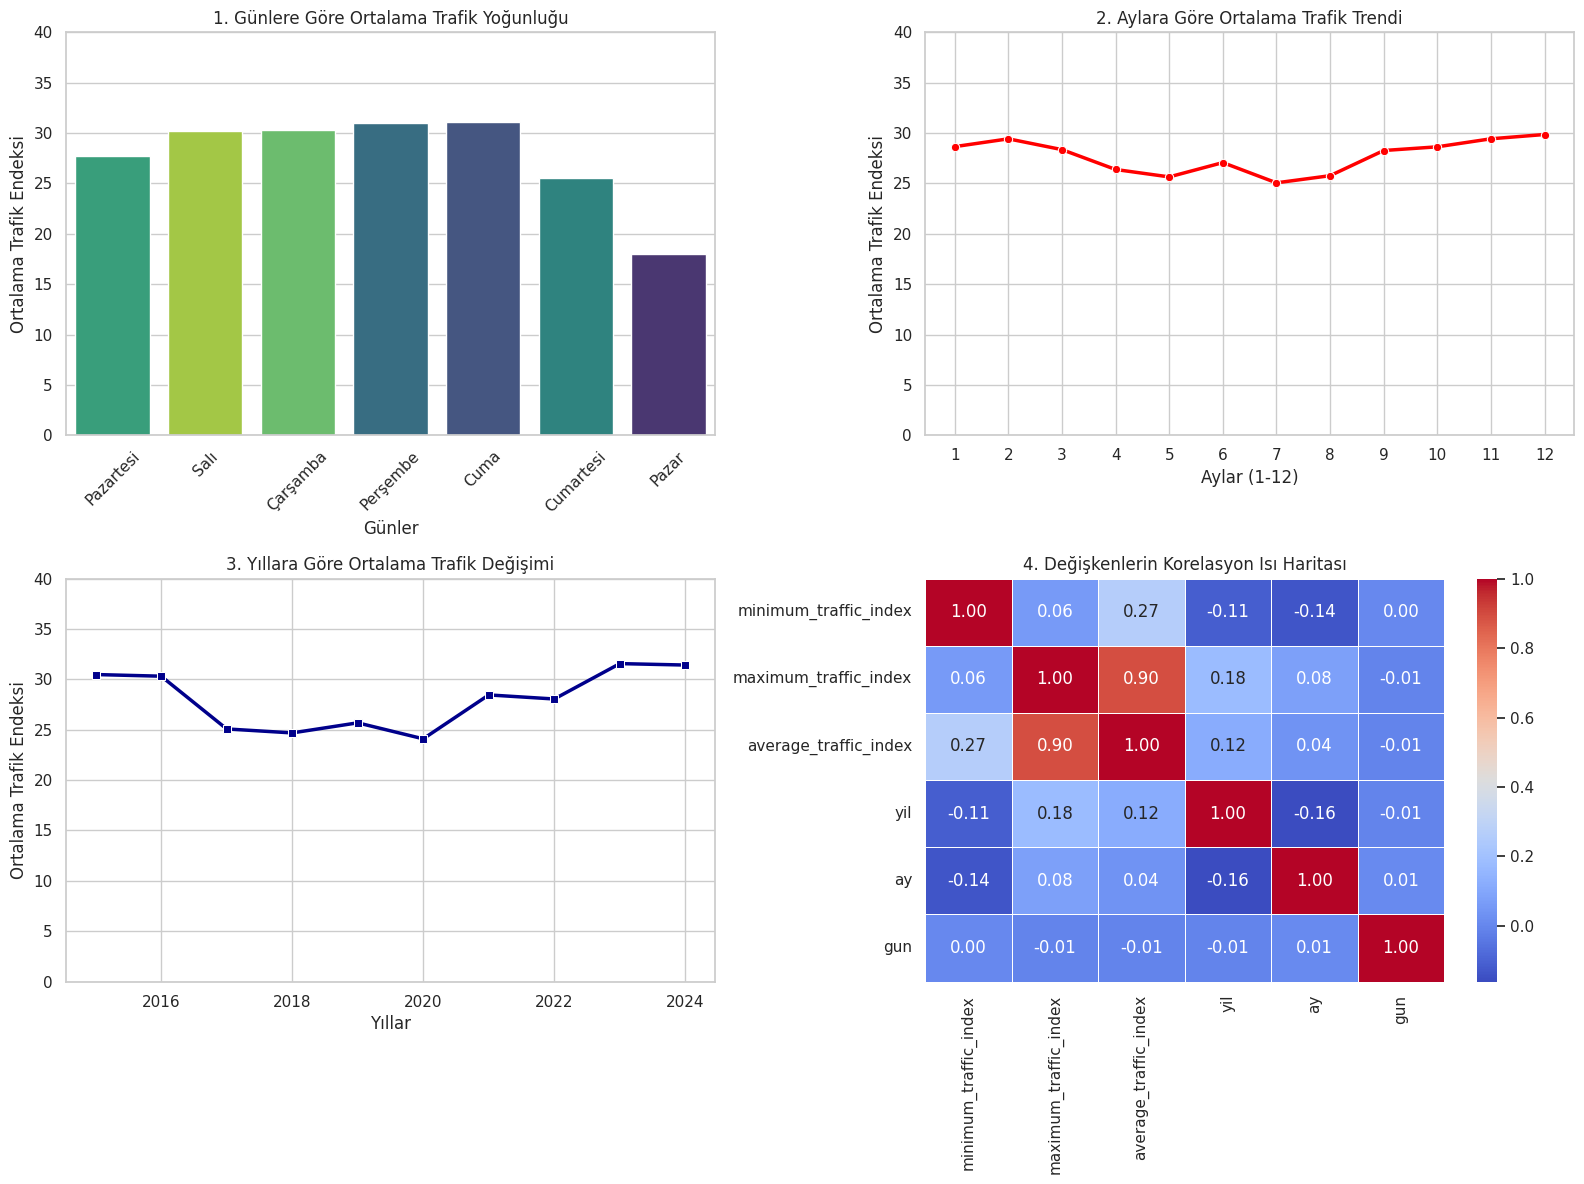

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

gun_sirasi = ['Pazartesi', 'Salı', 'Çarşamba', 'Perşembe', 'Cuma', 'Cumartesi', 'Pazar']

# --- GRAFİK 1: Günlere Göre Ortalama Trafik Yoğunluğu ---
plt.subplot(2, 2, 1)
sns.barplot(x='gun_adi', y='average_traffic_index', data=df, order=gun_sirasi, hue='gun_adi', palette='viridis', errorbar=None, legend=False)
plt.title('1. Günlere Göre Ortalama Trafik Yoğunluğu')
plt.xlabel('Günler')
plt.ylabel('Ortalama Trafik Endeksi')
plt.xticks(rotation=45)
plt.ylim(0, 40) # Ölçeği 0 ile 40 arasında sabitleyerek netliği artırıyoruz

# --- GRAFİK 2: Aylara Göre Ortalama Trafik Yoğunluğu ---
plt.subplot(2, 2, 2)
aylik_trafik = df.groupby('ay')['average_traffic_index'].mean().reset_index()
sns.lineplot(x='ay', y='average_traffic_index', data=aylik_trafik, marker='o', color='red', linewidth=2.5)
plt.title('2. Aylara Göre Ortalama Trafik Trendi')
plt.xlabel('Aylar (1-12)')
plt.ylabel('Ortalama Trafik Endeksi')
plt.xticks(range(1, 13))
plt.ylim(0, 40) # Eksen 0'dan başlasın ki dalgalanmanın gerçek boyutu görünsün

# --- GRAFİK 3: Yıllara Göre Trafik Yoğunluğu Değişimi ---
plt.subplot(2, 2, 3)
yillik_trafik = df.groupby('yil')['average_traffic_index'].mean().reset_index()
sns.lineplot(x='yil', y='average_traffic_index', data=yillik_trafik, marker='s', color='darkblue', linewidth=2.5)
plt.title('3. Yıllara Göre Ortalama Trafik Değişimi')
plt.xlabel('Yıllar')
plt.ylabel('Ortalama Trafik Endeksi')
plt.ylim(0, 40) # Eksen 0'dan başlayarak yıllar içindeki sakin değişimi göstersin

# --- GRAFİK 4: Sayısal Değişkenlerin Korelasyon Matrisi ---
plt.subplot(2, 2, 4)
korelasyon = df[['minimum_traffic_index', 'maximum_traffic_index', 'average_traffic_index', 'yil', 'ay', 'gun']].corr()
sns.heatmap(korelasyon, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('4. Değişkenlerin Korelasyon Isı Haritası')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Girdi (Özellikler) ve Çıktı (Hedef) değişkenlerimizi seçiyoruz
X = df[['yil', 'ay', 'gun']]
y = df['average_traffic_index']

# 2. Veri setimizi %80 Eğitim, %20 Test olacak şekilde ikiye bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Basit ve savunulabilir bir model olan Random Forest Regressor nesnesini oluşturuyoruz
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 4. Modeli eğitim verilerimizle eğitiyoruz (Öğrenme süreci)
model.fit(X_train, y_train)

# 5. Test verilerimizi kullanarak tahminler yapıyoruz
y_pred = model.predict(X_test)

# 6. Modelin başarısını ölçmek için performans metriklerini hesaplıyoruz
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performans Sonuçları ---")
print(f"Ortalama Mutlak Hata (MAE): {mae:.2f}")
print(f"R-kare (R2) Skoru: {r2:.2f}")

--- Model Performans Sonuçları ---
Ortalama Mutlak Hata (MAE): 4.93
R-kare (R2) Skoru: 0.32


In [ ]:
import pandas as pd

# Canlı tahmin için fonksiyon oluşturuyoruz
def trafik_tahmini_yap(girilen_tarih):
    try:
        # Kullanıcının girdiği metni tarih formatına çeviriyoruz
        tarih_nesnesi = pd.to_datetime(girilen_tarih)

        # Modelin anlayacağı girdi formatına (yil, ay, gun) bölüyoruz
        yil = tarih_nesnesi.year
        ay = tarih_nesnesi.month
        gun = tarih_nesnesi.day

        # Modeli beslemek için bir DataFrame oluşturuyoruz
        yeni_veri = pd.DataFrame([[yil, ay, gun]], columns=['yil', 'ay', 'gun'])

        # Az önce eğittiğimiz 'model' nesnesini kullanarak tahmin yapıyoruz
        tahmin_sonucu = model.predict(yeni_veri)[0]

        print(f"\n🔮 Tahmin Sonucu:")
        print(f"📅 Tarih: {girilen_tarih}")
        print(f"🚗 Modelin İstanbul için Tahmini Ortalama Trafik Endeksi: %{tahmin_sonucu:.2f}")

    except Exception as e:
        print("Hata! Lütfen tarihi YYYY-AA-GG formatında girdiğinizden emin olun. Örnek: 2026-07-05")

# --- CANLI TEST ALANI ---
# Aşağıdaki kutucuğa istediğin tarihi yazabilirsin.
# Örneğin teslim tarihinden sonraki bir günü (Pazar gününü) test edelim:
kullanici_tarihi = input("Lütfen tahmin etmek istediğiniz tarihi girin (Örn: 2026-07-05): ")
trafik_tahmini_yap(kullanici_tarihi)

Lütfen tahmin etmek istediğiniz tarihi girin (Örn: 2026-07-05): 2026-07-05

🔮 Tahmin Sonucu:
📅 Tarih: 2026-07-05
🚗 Modelin İstanbul için Tahmini Ortalama Trafik Endeksi: %34.37
